<a href="https://colab.research.google.com/github/AlifHammam/data-science-2026/blob/main/Pertemuan9_AlifHammamMultazam_240401010043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 9 - Algoritma Klasifikasi (Bagian 1): Prediksi Diagnosis Kanker

**Nama Lengkap:** Alif Hammam Multazam  
**NIM:** 240401010043  
**Kelas:** IF403

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Load Dataset & EDA Singkat

In [2]:
# Load dataset Breast Cancer Wisconsin (bawaan scikit-learn)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print('Shape:', X.shape)
print('\nDistribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))
X.head()

Shape: (569, 30)

Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Korelasi antar beberapa fitur utama
fitur_utama = ['mean radius', 'mean texture', 'mean perimeter',
               'mean area', 'mean smoothness']
print(X[fitur_utama].corr().round(2))

                 mean radius  mean texture  mean perimeter  mean area  \
mean radius             1.00          0.32            1.00       0.99   
mean texture            0.32          1.00            0.33       0.32   
mean perimeter          1.00          0.33            1.00       0.99   
mean area               0.99          0.32            0.99       1.00   
mean smoothness         0.17         -0.02            0.21       0.18   

                 mean smoothness  
mean radius                 0.17  
mean texture               -0.02  
mean perimeter              0.21  
mean area                   0.18  
mean smoothness             1.00  


## 3. Preprocessing Data

In [4]:
# Train-Test Split 80:20 dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape, '| Test:', X_test.shape)

# StandardScaler diperlukan untuk Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Train: (455, 30) | Test: (114, 30)


## 4. Model 1: Logistic Regression

In [5]:
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print('5 fitur paling berpengaruh terhadap prediksi:')
print(coef_df.head())

5 fitur paling berpengaruh terhadap prediksi:
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


## 5. Model 2: Decision Tree

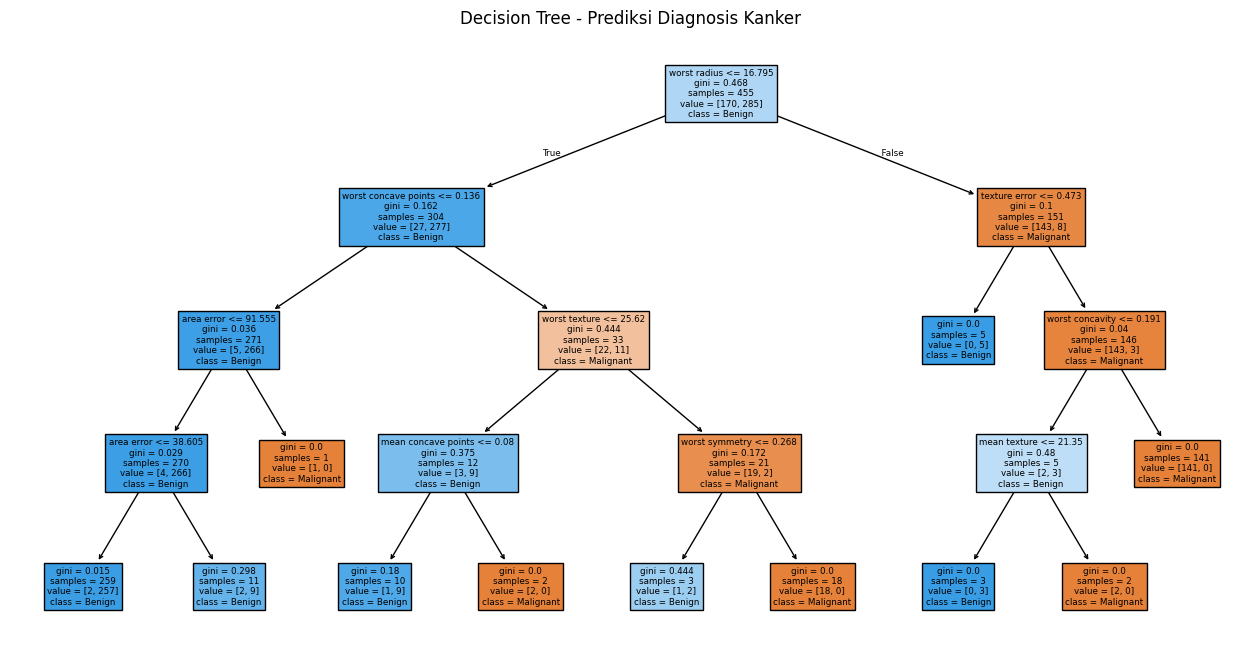

In [6]:
# Decision Tree tidak membutuhkan feature scaling
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], filled=True)
plt.title('Decision Tree - Prediksi Diagnosis Kanker')
plt.show()

## 6. Evaluasi & Perbandingan Model

In [7]:
for name, y_pred in [('Logistic Regression', y_pred_log),
                      ('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.3f}")


=== Logistic Regression ===
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


### Diskusi Hasil

- **Recall** menjadi metrik paling kritis pada kasus diagnosis kanker, karena False Negative (pasien sakit yang terdeteksi sehat) jauh lebih berbahaya dibanding False Positive (pasien sehat yang perlu pemeriksaan lanjutan).
- Berdasarkan hasil evaluasi di atas, model dengan Recall lebih tinggi lebih diprioritaskan untuk digunakan pada konteks medis, meskipun Accuracy kedua model relatif tinggi dan berdekatan.
- Accuracy saja tidak cukup untuk menilai model pada kasus medis, karena dapat menyembunyikan kegagalan mendeteksi kasus positif (mirip dengan accuracy paradox).

## Kesimpulan

Pada praktikum pertemuan kesembilan ini saya mempelajari dua algoritma klasifikasi dasar, yaitu Logistic Regression dan Decision Tree, beserta metrik evaluasi klasifikasi berupa Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score.

Melalui dataset Breast Cancer Wisconsin, saya memahami cara melatih model klasifikasi biner, melakukan feature scaling untuk Logistic Regression, memvisualisasikan struktur Decision Tree, serta membandingkan performa kedua model menggunakan berbagai metrik evaluasi. Saya juga memahami mengapa Recall menjadi metrik yang lebih diutamakan dibanding Accuracy pada kasus diagnosis medis, karena False Negative memiliki risiko yang jauh lebih besar.

Keterbatasan pada praktikum ini adalah belum dilakukan hyperparameter tuning secara mendalam (mis. GridSearchCV) sehingga performa model yang diperoleh mungkin belum optimal. Namun, praktikum ini memberikan pemahaman yang baik mengenai perbandingan model klasifikasi linear dan berbasis pohon keputusan, serta pentingnya memilih metrik evaluasi sesuai konteks masalah.